# Домашнє завдання 10. MLP з nn.Sequential
    Дата заняття: 23.06.2026 (вт)
    Модуль: Модуль 4. Основи нейронних мереж

### Мета
Побудувати першу багатошарову PyTorch-модель через nn.Sequential.

## Завдання
Створити notebook homework_10_mlp_sequential.ipynb.

## MLP для простого табличного датасета

### Завдання

1. Використайте один невеликий датасет зі sklearn.datasets, наприклад load_diabetes або load_breast_cancer.
2. Розділіть дані на train і test.
3. За потреби масштабуйте ознаки через StandardScaler.
4. Побудуйте MLP через nn.Sequential:
    - Linear;
    - ReLU;
    - Linear;
    - ReLU;
    - фінальний Linear.
5. Виберіть відповідну функцію втрат для задачі.
6. Навчіть модель у train loop.
7. Порахуйте 1-2 метрики на test set.
8. Виведіть приклади реальних і передбачених значень.
9. Напишіть короткий висновок: чи модель навчилася краще, ніж випадковий або дуже простий baseline.

#### Що здати
    Файл homework_10_mlp_sequential.ipynb.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

import torch 
import torch.nn as nn
import torch.optim as optim



In [7]:
data = load_breast_cancer()
X, y = data.data, data.target

np.set_printoptions(suppress=True)
X.shape
print(X)
print(f"Ознаки: {data.feature_names}")
print(f"Кількість зразків: {X.shape[0]}")
print(f"Кількість ознак: {X.shape[1]}")
print(f"Кількість класів: {len(np.unique(y))}")
print(f"Цільові класи: {data.target_names}")



[[ 17.99     10.38    122.8     ...   0.2654    0.4601    0.1189 ]
 [ 20.57     17.77    132.9     ...   0.186     0.275     0.08902]
 [ 19.69     21.25    130.      ...   0.243     0.3613    0.08758]
 ...
 [ 16.6      28.08    108.3     ...   0.1418    0.2218    0.0782 ]
 [ 20.6      29.33    140.1     ...   0.265     0.4087    0.124  ]
 [  7.76     24.54     47.92    ...   0.        0.2871    0.07039]]
Ознаки: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Кількість зразків: 569
Кількі

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")


X_train: (455, 30)
X_test: (114, 30)


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_test_tensor: {y_test_tensor.shape}")
print(f"y_test_tensor: {y_test_tensor.shape}")

X_train_tensor: torch.Size([455, 30])
y_train_tensor: torch.Size([455])
X_test_tensor: torch.Size([114])
y_test_tensor: torch.Size([114])


In [19]:
input_dim = X_train_tensor.shape[1]

model = nn.Sequential(
    nn.Linear(input_dim, 64),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.5),
    
    nn.Linear(32, 2)
)

print(model)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=32, out_features=2, bias=True)
)


In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
train_losses = []
test_losses = []

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())


    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        test_loss = loss_fn(test_logits, y_test_tensor)
        test_losses.append(test_loss.item())

    print(f"epoch: {epoch}, train_loss: {train_losses[-1]}, test_loss: {test_losses[-1]}")

epoch: 0, train_loss: 0.6970959305763245, test_loss: 0.6699966788291931
epoch: 1, train_loss: 0.6828795075416565, test_loss: 0.6529321670532227
epoch: 2, train_loss: 0.6657893061637878, test_loss: 0.6364650130271912
epoch: 3, train_loss: 0.6351345181465149, test_loss: 0.6204835772514343
epoch: 4, train_loss: 0.627608597278595, test_loss: 0.6050438284873962
epoch: 5, train_loss: 0.6214311718940735, test_loss: 0.5899418592453003
epoch: 6, train_loss: 0.5956384539604187, test_loss: 0.574860155582428
epoch: 7, train_loss: 0.5713543891906738, test_loss: 0.5597397089004517
epoch: 8, train_loss: 0.5620731711387634, test_loss: 0.5447456240653992
epoch: 9, train_loss: 0.5543015599250793, test_loss: 0.5297201871871948
epoch: 10, train_loss: 0.5392453074455261, test_loss: 0.5146231055259705
epoch: 11, train_loss: 0.5308723449707031, test_loss: 0.49950915575027466
epoch: 12, train_loss: 0.5080820322036743, test_loss: 0.48444104194641113
epoch: 13, train_loss: 0.4988496005535126, test_loss: 0.46929

після додавання nn.Dropout(0.5) та зменшення кількості епох, модель навчається правильно, ознак перенавчання немає. Обидва показника зменшуються рівномірно 

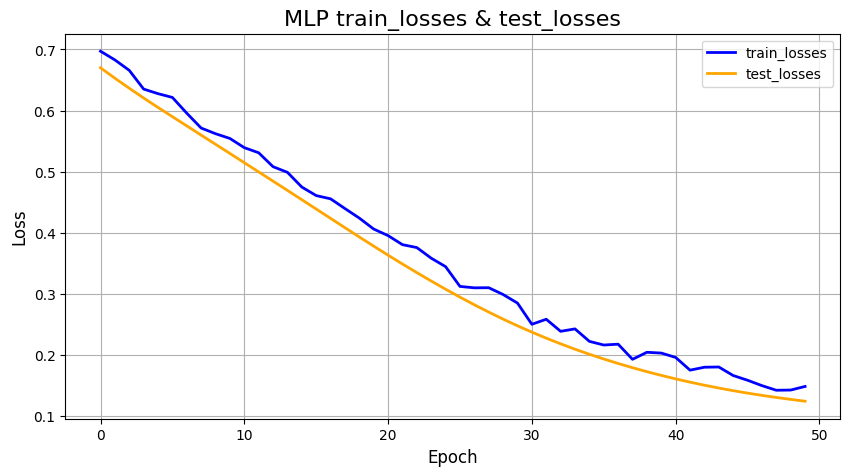

In [26]:
from cProfile import label


plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='train_losses', color='blue', linewidth=2)
plt.plot(test_losses, label='test_losses', color='orange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('MLP train_losses & test_losses', fontsize=16)
plt.legend()
plt.grid()
plt.show()

Спостерігаємоє рівномірне зменшення показників, без ознак перенавчання. Модель працює корректно.

In [22]:
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    preds = torch.argmax(logits, dim=1).cpu().numpy()


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


cm = confusion_matrix(y_test, preds)
print(cm)

accuracy = accuracy_score(y_test, preds)
print(accuracy)

precision = precision_score(y_test, preds)
print(precision)

recall = recall_score(y_test, preds)
print(recall)

f1 = f1_score(y_test, preds)
print(f1)


[[38  4]
 [ 1 71]]
0.956140350877193
0.9466666666666667
0.9861111111111112
0.9659863945578231


- З усіх 114 ознак модель назвала правильно 109, бачимо по accuracy
- модель назвала правильно клас в 94%, бачимо по precision 
- 98%  модель знаходе праильний реальний клас, бачимо по recall
- баланс зебережений 96% - f1

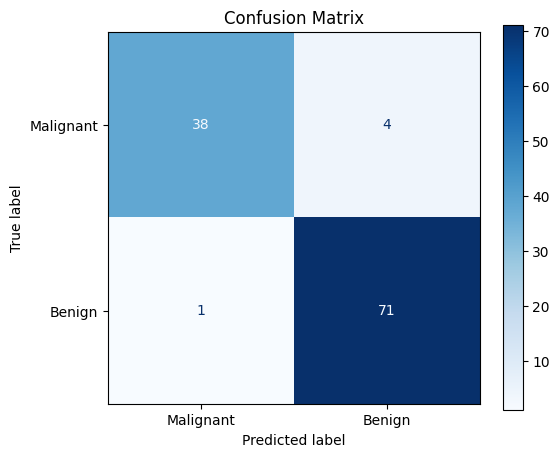

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


модель навчається досить добре, але навні критичні помилки False Negative - 4. Модель назвала злоякісну  пухлину, як доброякісну. 

In [35]:
comparison = pd.DataFrame({
    'Real': y_test,
    'Pred': preds,
})

print(comparison)
print(comparison.sample(20))

     Real  Pred
0       0     0
1       1     1
2       0     0
3       1     1
4       0     0
..    ...   ...
109     0     0
110     1     1
111     0     0
112     1     1
113     1     1

[114 rows x 2 columns]
     Real  Pred
83      1     1
35      0     1
89      1     1
2       0     0
66      1     1
7       0     0
85      1     1
98      0     0
59      1     1
14      0     0
100     0     0
65      0     1
102     0     0
107     0     0
112     1     1
81      1     1
53      0     1
24      1     1
6       1     1
3       1     1


Модель навчилась, але допускає критичні помилки. В даному випадку мова йде про життя людини. Пацієнт не отримує вчасно лікування. 
модель краще за випадкове вгадування, її точність 95% - це досить високий результат. FN - 4 - в медичній практиці - це критично.

In [39]:

counts = np.bincount(y_test)
most_frequent = counts.max()
baseline = most_frequent / len(y_test)
print(f"baseline - {baseline}")

print(f"MLP accuracy: {accuracy}")

print(f"Покращення: {(accuracy - baseline)*100:.1f}%")

baseline - 0.631578947368421
MLP accuracy: 0.956140350877193
Покращення: 32.5%


Модель навчина на 32,5% краще за базовий рівень.

Модель можливо використовувати, виключно, як допоміжний інструмент в роботі медичного працівника. 